<a href="https://colab.research.google.com/github/nesbita/ML-Collision-Severity-YOLO-Detection/blob/main/Ariana_Nesbit_Ass2_T25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U ultralytics
!pip install -q grad-cam
from ultralytics import YOLO
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

shutil.copytree('/content/drive/MyDrive/kitti3k_yolo', '/content/kitti3k_yolo')
print('Done.')

Mounted at /content/drive
Done.


In [ ]:
## BEST MODEL CONFIG 3

# load config
model = YOLO('/content/drive/MyDrive/config3_best.pt')

# get the underlying PyTorch model
pytorch_model = model.model
pytorch_model.eval()

print('Model loaded.')
print(type(pytorch_model))

Model loaded.
<class 'ultralytics.nn.tasks.DetectionModel'>


In [ ]:
## FIND LAYERS

# print layer names to help select
for name, module in pytorch_model.named_modules():
    print(name)


model
model.0
model.0.conv
model.0.bn
model.0.act
model.1
model.1.conv
model.1.bn
model.2
model.2.cv1
model.2.cv1.conv
model.2.cv1.bn
model.2.cv2
model.2.cv2.conv
model.2.cv2.bn
model.2.m
model.2.m.0
model.2.m.0.cv1
model.2.m.0.cv1.conv
model.2.m.0.cv1.bn
model.2.m.0.cv2
model.2.m.0.cv2.conv
model.2.m.0.cv2.bn
model.3
model.3.conv
model.3.bn
model.4
model.4.cv1
model.4.cv1.conv
model.4.cv1.bn
model.4.cv2
model.4.cv2.conv
model.4.cv2.bn
model.4.m
model.4.m.0
model.4.m.0.cv1
model.4.m.0.cv1.conv
model.4.m.0.cv1.bn
model.4.m.0.cv2
model.4.m.0.cv2.conv
model.4.m.0.cv2.bn
model.5
model.5.conv
model.5.bn
model.6
model.6.cv1
model.6.cv1.conv
model.6.cv1.bn
model.6.cv2
model.6.cv2.conv
model.6.cv2.bn
model.6.m
model.6.m.0
model.6.m.0.cv1
model.6.m.0.cv1.conv
model.6.m.0.cv1.bn
model.6.m.0.cv2
model.6.m.0.cv2.conv
model.6.m.0.cv2.bn
model.6.m.0.cv3
model.6.m.0.cv3.conv
model.6.m.0.cv3.bn
model.6.m.0.m
model.6.m.0.m.0
model.6.m.0.m.0.cv1
model.6.m.0.m.0.cv1.conv
model.6.m.0.m.0.cv1.bn
model.6.m

In [ ]:
# select target layers
target_layers = [
    pytorch_model.model[2],
    pytorch_model.model[22],
]

# load and prepare image
img_path = '/content/kitti3k_yolo/images/val/000136.png'
img = np.array(Image.open(img_path))
img_float = img.astype(np.float32) / 255.0

# resize to 640x640 for YOLO
img_resized = cv2.resize(img, (640, 640))
img_resized_float = img_resized.astype(np.float32) / 255.0

# prepare tensor
tensor = torch.from_numpy(img_resized_float).permute(2, 0, 1).unsqueeze(0)

print('Image prepared.')
print('Tensor shape:', tensor.shape)

Image prepared.
Tensor shape: torch.Size([1, 3, 640, 640])


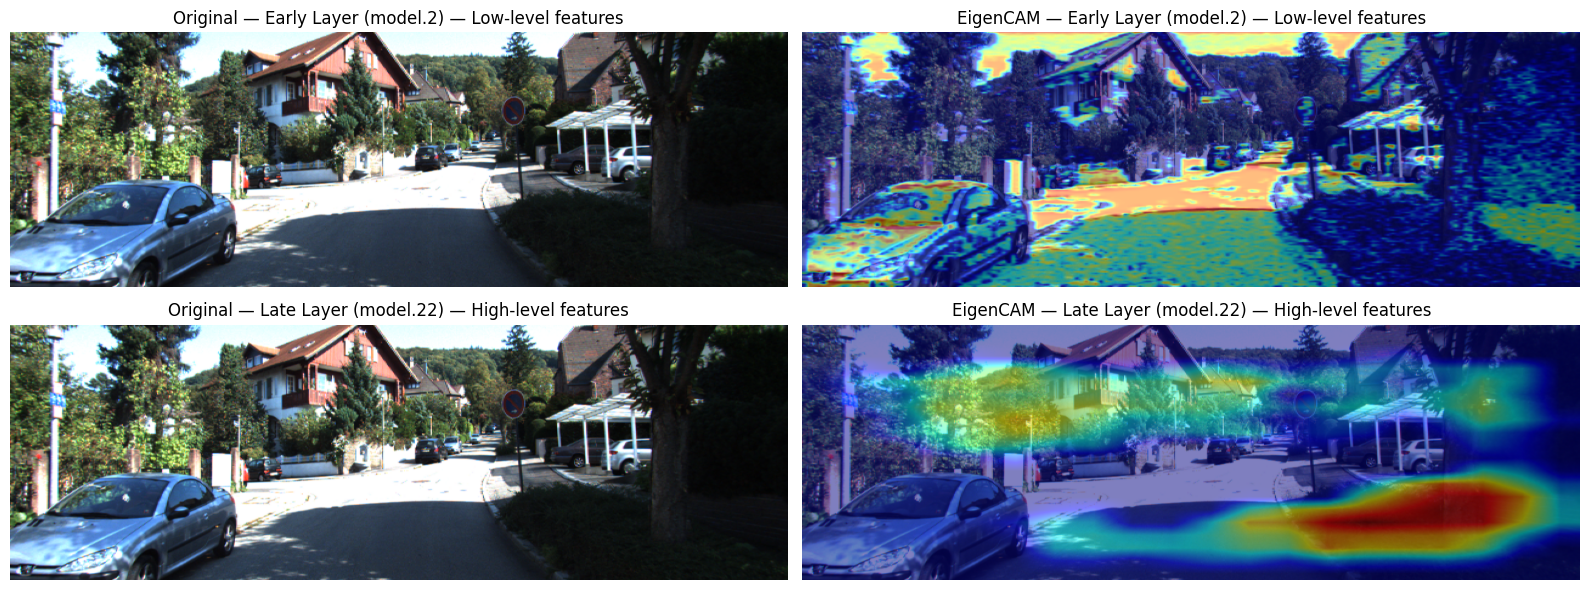

In [ ]:
## GENERATE HEATMAP

# wrapper to make YOLO compatible with EigenCAM
class YOLOWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        output = self.model(x)
        # return first element if tuple
        if isinstance(output, tuple):
            return output[0]
        return output

wrapped_model = YOLOWrapper(pytorch_model)

# use original aspect ratio instead
img_resized_correct = cv2.resize(img, (640, 192))  # maintain approximate ratio
img_resized_float_correct = img_resized_correct.astype(np.float32) / 255.0
tensor_correct = torch.from_numpy(img_resized_float_correct).permute(2, 0, 1).unsqueeze(0)

# pad to 640x640 for YOLO
pad_h = 640 - 192
tensor_padded = torch.nn.functional.pad(tensor_correct, (0, 0, 0, pad_h))

fig, axes = plt.subplots(2, 2, figsize=(16, 6))
layer_names = ['Early Layer (model.2) — Low-level features',
               'Late Layer (model.22) — High-level features']

for i, (layer, name) in enumerate(zip(target_layers, layer_names)):
    cam = EigenCAM(wrapped_model, [layer])
    grayscale_cam = cam(input_tensor=tensor)[0]

    visualization = show_cam_on_image(img_resized_float, grayscale_cam, use_rgb=True)

    # display with correct aspect ratio
    axes[i][0].imshow(img_resized, aspect='auto')
    axes[i][0].set_title(f'Original — {name}')
    axes[i][0].axis('off')

    axes[i][1].imshow(visualization, aspect='auto')
    axes[i][1].set_title(f'EigenCAM — {name}')
    axes[i][1].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eigencam_000136_v2.png', dpi=150, bbox_inches='tight')
plt.show()